In [111]:
#Importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as mpl

#Printing library versions for user clarification
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")


NumPy version: 2.5.1
pandas version: 3.0.5
matplotlib version: 3.11.1


We begin by loading the dataset and cleaning it by removing unnecessary columns & empty values.

In [112]:
#Loading Data into a Data frame

data = pd.read_csv("../data/players.csv")
print(len(data))
data.head()

1248


,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
data.info()
data.columns

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1248 non-null   str    
 1   team                        1248 non-null   str    
 2   team_country                1248 non-null   str    
 3   position                    1248 non-null   str    
 4   age                         1248 non-null   int64  
 5   birth_year                  1248 non-null   int64  
 6   club                        907 non-null    str    
 7   games                       1248 non-null   int64  
 8   games_starts                1248 non-null   int64  
 9   minutes                     1039 non-null   float64
 10  minutes_90s                 1039 non-null   float64
 11  goals                       1039 non-null   float64
 12  assists                     1039 non-null   float64
 13  goals_assists               1039 non-null   

Index(['player', 'team', 'team_country', 'position', 'age', 'birth_year',
       'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals',
       'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att',
       'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_game', 'minutes_pct', 'minutes_per_start',
       'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs',
       'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus',
       'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls',
       'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won',
       'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts',
       'gk_minutes', 'gk_goals_against', 

Since we are only focusing on outfield players, we can remove all of the goalkeeper statistics.

In [114]:
gk_columns = data.columns[range(54,72,1)]
data = data.drop(columns=gk_columns)
data.columns

Index(['player', 'team', 'team_country', 'position', 'age', 'birth_year',
       'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals',
       'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att',
       'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_game', 'minutes_pct', 'minutes_per_start',
       'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs',
       'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus',
       'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls',
       'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won',
       'pens_won', 'pens_conceded', 'own_goals'],
      dtype='str')

Now we look for any empty values in the dataset and remove them where appropriate.

In [115]:
data.isna().any()
data.isna().sum()

player                         0
team                           0
team_country                   0
position                       0
age                            0
birth_year                     0
club                         341
games                          0
games_starts                   0
minutes                      209
minutes_90s                  209
goals                        209
assists                      209
goals_assists                209
goals_pens                   209
pens_made                    209
pens_att                     209
cards_yellow                 209
cards_red                    209
goals_per90                  209
assists_per90                209
goals_assists_per90          209
goals_pens_per90             209
goals_assists_pens_per90     209
shots                        209
shots_on_target              209
shots_on_target_pct          568
shots_per90                  209
shots_on_target_per90        209
goals_per_shot               568
goals_per_

We see that the variables of interest like goals, assists and minutes all have 209 empty records, which we can assume means that the data is missing in all variables for the same 209 players. Also, the pens_won and pens_conceded columns have no non-empty entries. We need to remove these records and columns from the dataset. 

In [116]:
print(len(data))
data = data.dropna(subset=["goals", "minutes", "assists"])
print(len(data))
print(1248-209)
data = data.drop(columns=["pens_won", "pens_conceded"])

1248
1039
1039


We have removed all rows with empty values in our main variables and we see that the the amount of rows drops by 209, which confirms that the same players had empty entries in all of our main columns. 

Now we have successfully cleaned our data, we can begin to analyse the data.

In [117]:
data.describe()

,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,...,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals
count,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,...,1039.000000,920.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000,1039.000000
mean,27.463908,1998.022137,3.164581,2.202117,203.474495,2.259865,0.283927,0.215592,0.499519,0.268527,...,-0.552281,-0.156022,0.001925,2.321463,2.221367,0.354187,3.205005,1.673725,1.948989,0.012512
std,4.198173,4.196578,1.664215,1.873030,158.361191,1.757987,0.834724,0.590310,1.169519,0.786495,...,7.042085,8.377231,0.043853,2.489019,2.833036,0.886453,5.676349,2.200103,2.493208,0.119558
min,17.000000,1985.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-90.000000,-90.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,1995.000000,2.000000,1.000000,71.000000,0.800000,0.000000,0.000000,0.000000,0.000000,...,-1.330000,-1.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,1998.000000,3.000000,2.000000,180.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,30.000000,2001.000000,4.000000,3.000000,288.000000,3.200000,0.000000,0.000000,1.000000,0.000000,...,0.820000,1.470000,0.000000,4.000000,3.000000,0.000000,4.000000,2.000000,3.000000,0.000000
max,41.000000,2008.000000,8.000000,8.000000,810.000000,9.000000,10.000000,7.000000,14.000000,9.000000,...,90.000000,91.000000,1.000000,15.000000,20.000000,9.000000,54.000000,15.000000,20.000000,2.000000


Since statistics such as goals and assists are discrete, it makes sense to represent these in bar charts.

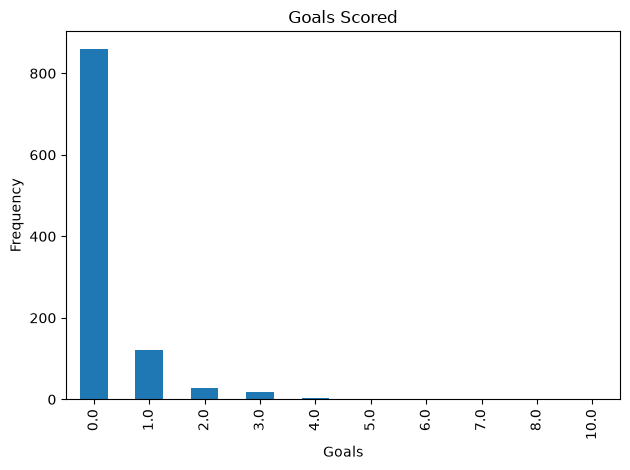

In [118]:
#Getting the count of goals scored by each player
counts_goals = data['goals'].value_counts().sort_index()

#Making the Plot
counts_goals.plot(kind='bar')
mpl.title('Goals Scored')
mpl.xlabel('Goals')
mpl.ylabel('Frequency')
mpl.tight_layout()
mpl.show()

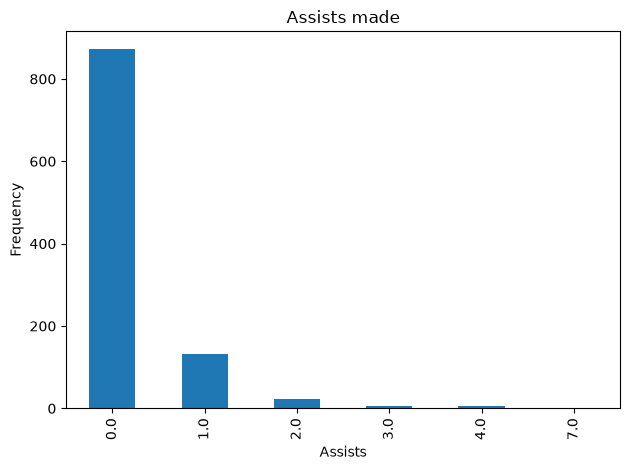

In [119]:
#Getting the count of goals scored by each player
counts_assists = data['assists'].value_counts().sort_index()

#Making the Plot
counts_assists.plot(kind='bar')
mpl.title('Assists made')
mpl.xlabel('Assists')
mpl.ylabel('Frequency')
mpl.tight_layout()
mpl.show()